<a href="https://colab.research.google.com/github/hiranshree/webtemp1/blob/main/Small_Buildings_breakout_heatmap_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analyzing 98 buildings...
------------------------------
SUCCESS: Heatmap saved as Enernoc_Breakout_Heatmap.png
Breakout Detection Math: 3.26s
Total Execution Time: 13.18s
------------------------------


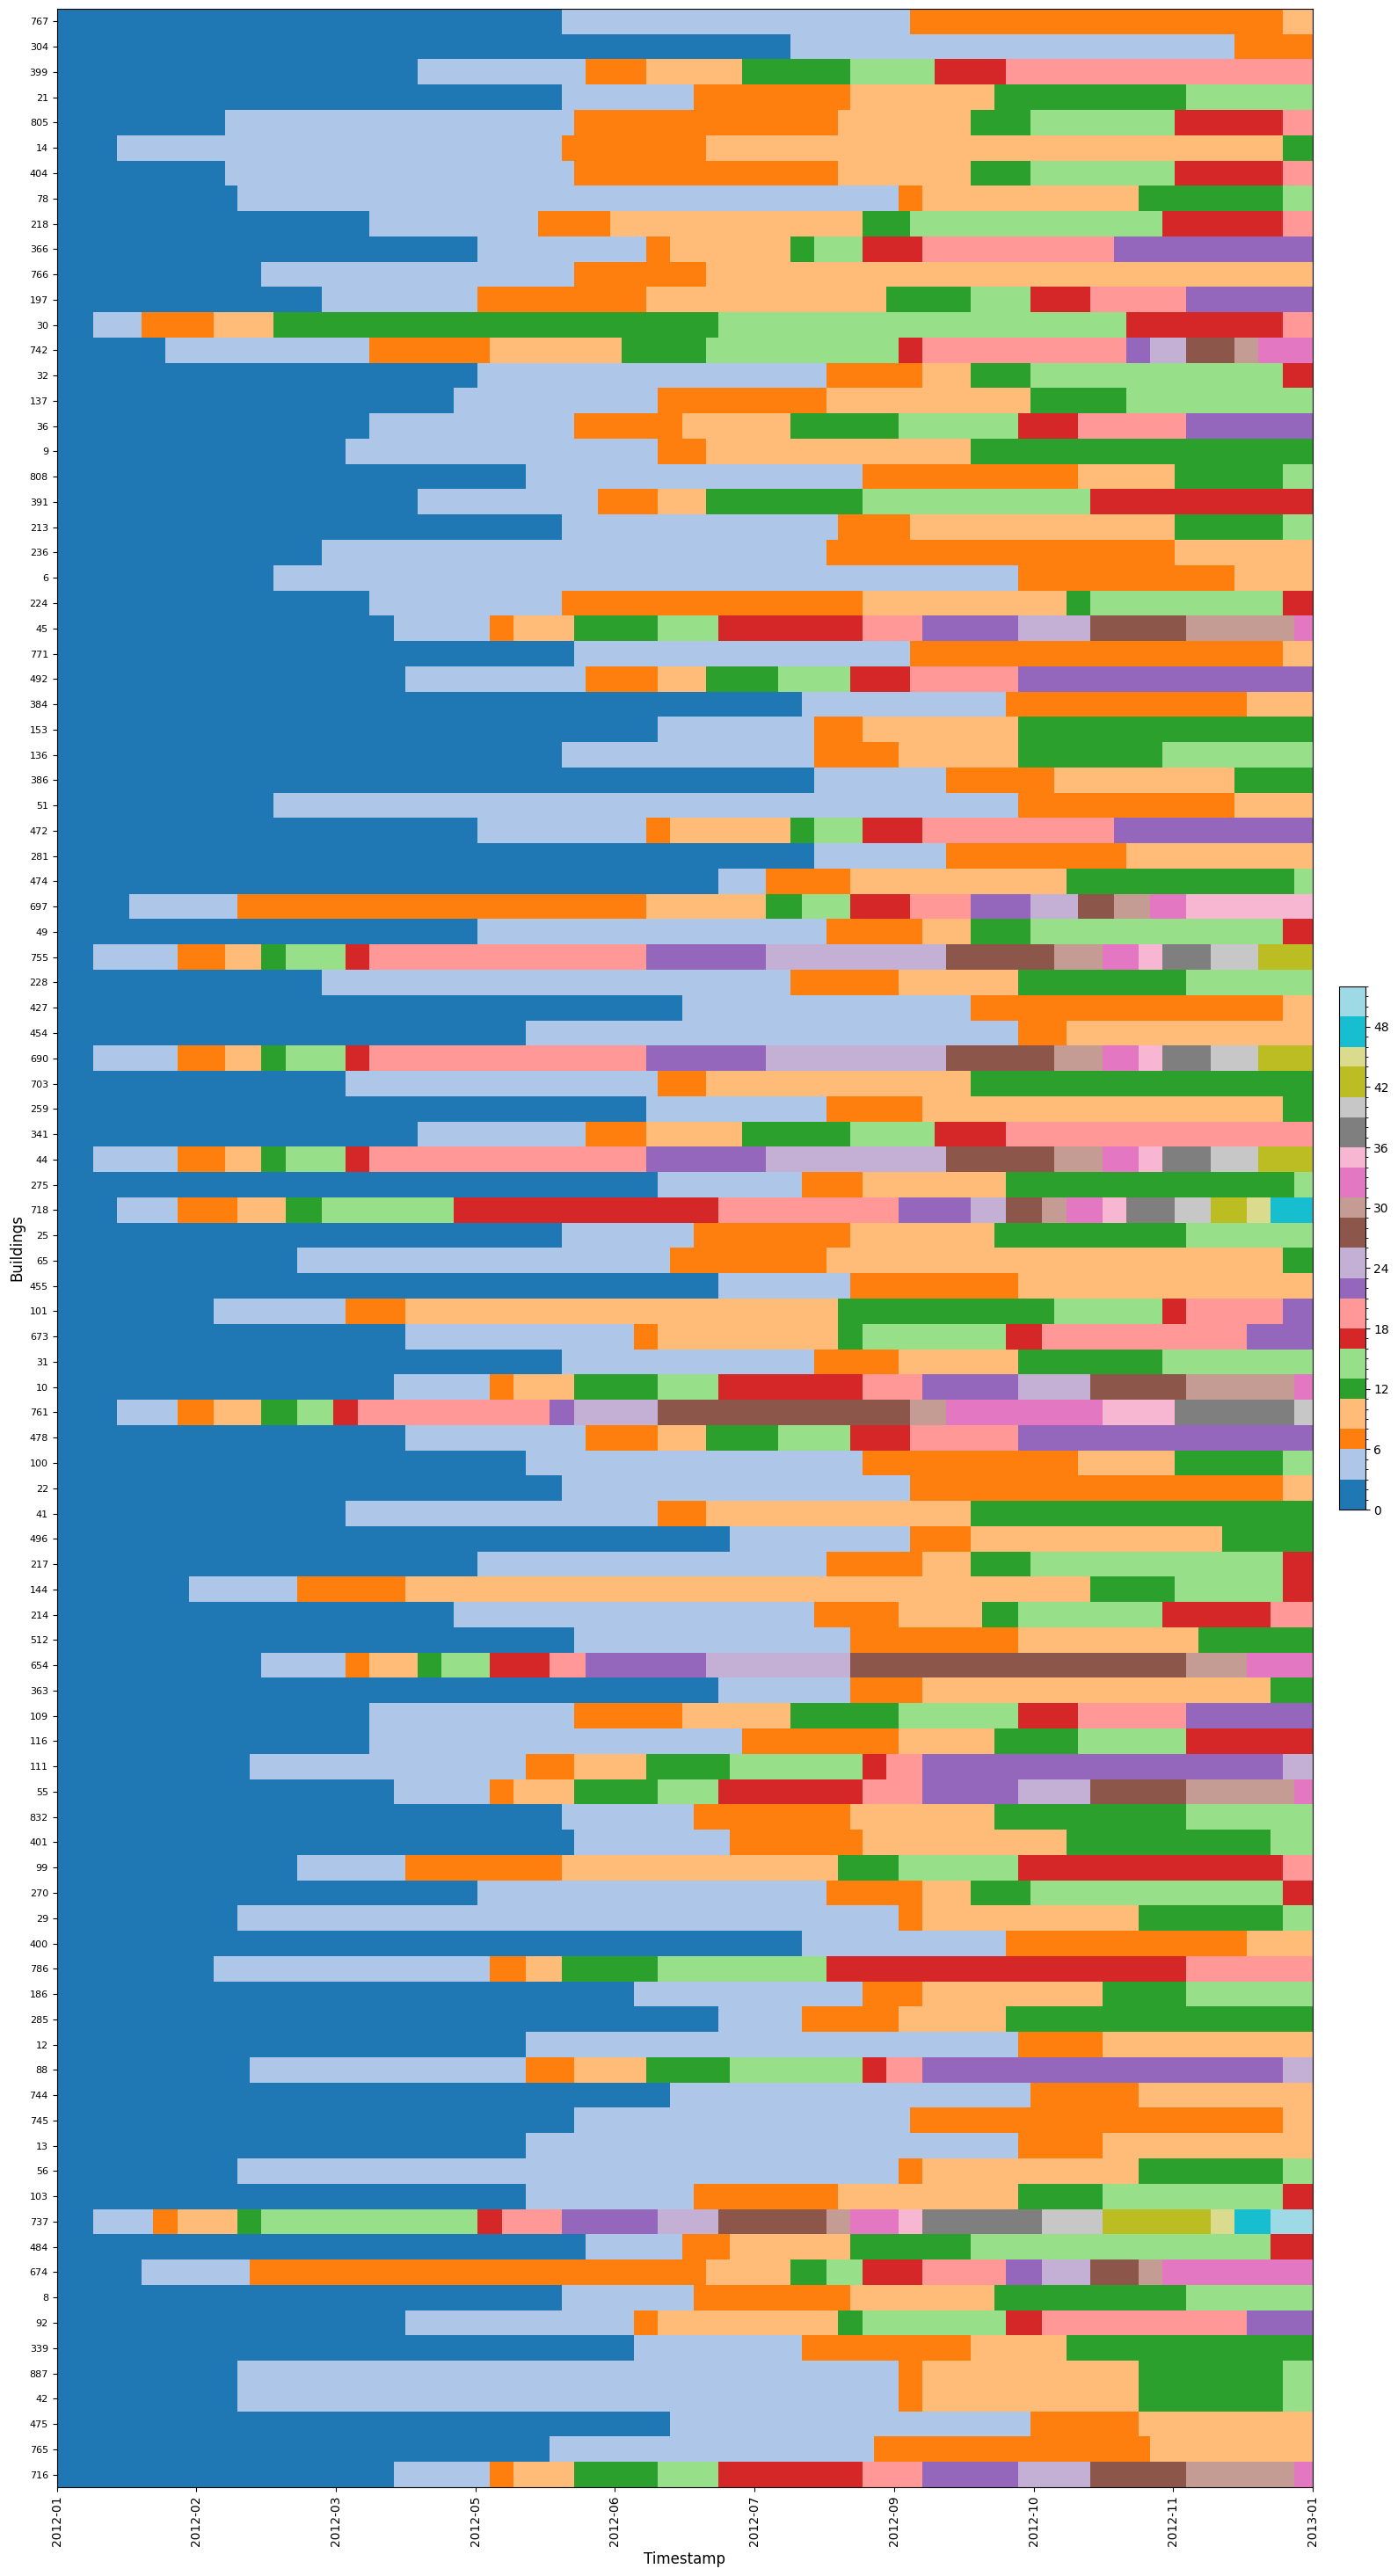

In [7]:
import pandas as pd
import numpy as np
!pip install ruptures
import ruptures as rpt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

def breakout_heatmap(filename):
    # --- 1. Load and Pre-process Data ---
    start_total = time.perf_counter()

    try:
        data = pd.read_csv(filename)
        data['Timestamp'] = pd.to_datetime(data['Timestamp'])
        data = data.sort_values('Timestamp').reset_index(drop=True)
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    building_cols = data.columns.drop('Timestamp')

    # Parameters
    min_size = 168  # Minimum segment size (1 week of hourly data)
    penalty = 20    # Penalty for PELT (Higher = fewer breakouts)
    jump_val = 168    # Increase (e.g., to 12 or 24) for much faster processing

    # 2. Use a dictionary to collect segments (avoids DataFrame Fragmentation)
    results_dict = {}

    print(f"Analyzing {len(building_cols)} buildings...")

    # --- 3. Core Breakout Detection Loop ---
    loop_start = time.perf_counter()

    for building in building_cols:
        signal = data[building].values

        # Clean data (Modern pandas ffill/bfill)
        if np.any(np.isnan(signal)) or np.any(np.isinf(signal)):
            signal = pd.Series(signal).interpolate().bfill().ffill().values

        if len(signal) < min_size:
            continue

        try:
            # Normalize signal (StandardScaler logic) so penalty works across all scales
            std_signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-6)

            # PELT algorithm
            algo = rpt.Pelt(model="l2", min_size=min_size, jump=jump_val).fit(std_signal)
            breakpoints = algo.predict(pen=penalty)

            # Map breakpoints to segment IDs
            segments = np.zeros(len(signal), dtype=int)
            start = 0
            for idx, bp in enumerate(breakpoints):
                segments[start:bp] = idx
                start = bp

            results_dict[building] = segments

        except Exception as e:
            print(f"Segmentation failed for building {building}: {e}")
            continue

    # Convert dictionary to DataFrame all at once to keep memory contiguous
    segment_labels = pd.DataFrame(results_dict, index=data.index)

    loop_end = time.perf_counter()

    # --- 4. Filtering and Plotting ---
    # Only plot buildings where more than 1 segment was found
    valid_cols = [c for c in segment_labels.columns if segment_labels[c].nunique() > 1]

    if not valid_cols:
        print("No breakouts detected in any building with the current penalty.")
        print(f"Total time: {loop_end - start_total:.2f} seconds")
        return

    # Prepare data for heatmap
    heatmap_data = segment_labels[valid_cols].T.values
    num_segments = int(heatmap_data.max() + 1)

    # Dynamic figure height based on number of buildings
    fig_height = max(3, len(valid_cols) * 0.3)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    # Plot using a discrete colormap
    cmap = plt.get_cmap('tab20', num_segments)
    im = ax.imshow(heatmap_data, aspect='auto', cmap=cmap, interpolation='nearest')

    # Formatting Y-axis
    ax.set_yticks(np.arange(len(valid_cols)))
    ax.set_yticklabels(valid_cols, fontsize=8)

    # Formatting X-axis (Dates)
    n_ticks = 10
    indices = np.linspace(0, len(data) - 1, n_ticks, dtype=int)
    ax.set_xticks(indices)
    ax.set_xticklabels(data['Timestamp'].dt.strftime('%Y-%m').iloc[indices], rotation=90)

    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Buildings", fontsize=12)

    # Add Colorbar
    norm = mcolors.BoundaryNorm(np.arange(num_segments + 1), cmap.N)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label('')

    plt.tight_layout()

    # Save and Show
    save_name = "Enernoc_Breakout_Heatmap.png"
    plt.savefig(save_name, dpi=300)

    end_total = time.perf_counter()

    # Final Statistics
    print("-" * 30)
    print(f"SUCCESS: Heatmap saved as {save_name}")
    print(f"Breakout Detection Math: {loop_end - loop_start:.2f}s")
    print(f"Total Execution Time: {end_total - start_total:.2f}s")
    print("-" * 30)

    plt.show()

# Run the function
if __name__ == "__main__":
    breakout_heatmap('/content/Electricity-30min.csv')